# Exercise 3 — Preparing Real-World Data for a Neural Network

Runnable code for the *Data* deliverable. The Spaceship Titanic dataset is
preprocessed for a network whose hidden layers use `tanh`, so the inputs are put
on a bounded, `tanh`-compatible scale. Every statistic used in a transformation
(median, most-frequent category, min/max) is fit **only on the training split** to
avoid data leakage.

In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

%matplotlib inline

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load train.csv; fall back to a public mirror so the notebook runs from a
# clean checkout even if the file is not present.
CSV = Path("train.csv")
if not CSV.exists():
    url = "https://raw.githubusercontent.com/You-sha/Spaceship-Titanic/main/train.csv"
    urllib.request.urlretrieve(url, CSV)

df = pd.read_csv(CSV)
print("Raw shape:", df.shape)
df.head()

Raw shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## A — Get to know the data

**Goal.** Each row is a passenger; the target `Transported` is a boolean —
whether the passenger was transported to another dimension during the
spacetime-anomaly incident. It is the binary label a classifier must predict.

In [2]:
y = df["Transported"].astype(int)
share_positive = y.mean()
print("Class balance (Transported):")
print(df["Transported"].value_counts(normalize=True).round(4).to_string())
print(f"\nShare of the positive class (True) = {share_positive:.4f}")

Class balance (Transported):
Transported
True     0.5036
False    0.4964

Share of the positive class (True) = 0.5036


**Features.** Splitting by type:

In [3]:
numerical = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
categorical = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP", "Name"]
identifier = ["PassengerId"]
print("Numerical :", numerical)
print("Categorical:", categorical)
print("Identifier :", identifier, "(dropped)")

Numerical : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Identifier : ['PassengerId'] (dropped)


**Missing values** per column (absolute count and percentage):

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


**Spending columns** — mean, median, maximum (on the full dataset). A mean
far above the median signals a right-skewed, heavy-tailed distribution.

In [5]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
spend_stats = df[spend_cols].agg(["mean", "median", "max"]).T.round(2)
spend_stats

,mean,median,max
RoomService,224.69,0.0,14327.0
FoodCourt,458.08,0.0,29813.0
ShoppingMall,173.73,0.0,23492.0
Spa,311.14,0.0,22408.0
VRDeck,304.85,0.0,24133.0


The mean sits far above the median for every spending column (e.g. `FoodCourt`
mean $\gg$ median $= 0$): most passengers spend nothing, while a few spend a great
deal — a strongly right-skewed, heavy-tailed shape that motivates the $\log(1+x)$
transform later.

## B — Split before you transform

Stratified 80/20 split with a fixed seed. **Why split first?** Every statistic used
to transform the data — imputation medians, the most-frequent category, and the
min/max used for scaling — must be learned from the training set only. If they were
computed on the full dataset and split afterwards, information from the test rows
would leak into the training pipeline and the reported performance would be
optimistic and untrustworthy.

In [6]:
feature_cols = [c for c in df.columns if c != "Transported"]
X = df[feature_cols]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

# Results-summary row 11: FoodCourt on the training set, before transforming
fc_mean = X_train["FoodCourt"].mean()
fc_median = X_train["FoodCourt"].median()
print(f"FoodCourt (train, raw): mean = {fc_mean:.2f}, median = {fc_median:.2f}")

Train: (6954, 13) | Test: (1739, 13)
FoodCourt (train, raw): mean = 452.61, median = 0.00


## C — Preprocess

### 1. Missing data

- **Numerical** (`Age` + the five spending columns): impute with the **median** —
  robust to the heavy right tails, so a few big spenders do not drag the fill value.
- **Categorical** (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`): impute with the
  **most frequent** category.

Both imputers are fit on the training set and merely applied to the test set.

In [7]:
num_cols = ["Age"] + spend_cols
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

Xtr = X_train.copy()
Xte = X_test.copy()

num_imputer = SimpleImputer(strategy="median")
Xtr[num_cols] = num_imputer.fit_transform(Xtr[num_cols])
Xte[num_cols] = num_imputer.transform(Xte[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
Xtr[cat_cols] = cat_imputer.fit_transform(Xtr[cat_cols])
Xte[cat_cols] = cat_imputer.transform(Xte[cat_cols])

fc_before = Xtr["FoodCourt"].to_numpy().copy()  # kept for Figure 6
print("NaN after imputation — train:", int(Xtr[num_cols + cat_cols].isna().sum().sum()),
      "| test:", int(Xte[num_cols + cat_cols].isna().sum().sum()))

NaN after imputation — train: 0 | test: 0


### 2. Categorical encoding (one-hot)

`OneHotEncoder(handle_unknown="ignore")` is fit on the training categories. A
category that appears **only in the test set** is encoded as all-zeros across that
feature's columns instead of raising an error, so the pipeline never breaks on an
unseen value.

In [8]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_tr = ohe.fit_transform(Xtr[cat_cols])
ohe_te = ohe.transform(Xte[cat_cols])
ohe_names = list(ohe.get_feature_names_out(cat_cols))
print("One-hot feature columns:", ohe_names)

One-hot feature columns: ['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True']


### 3. Feature engineering — `TotalSpend`

Sum of the five spending columns. `Cabin`, `Name`, and `PassengerId` are dropped
(free-text / identifiers with no direct numerical meaning for the network).

In [9]:
Xtr["TotalSpend"] = Xtr[spend_cols].sum(axis=1)
Xte["TotalSpend"] = Xte[spend_cols].sum(axis=1)
print("Added TotalSpend. Dropped:", ["Cabin", "Name", "PassengerId"])

Added TotalSpend. Dropped: ['Cabin', 'Name', 'PassengerId']


### 4. Heavy tails — $\log(1+x)$

The spending columns (and `TotalSpend`) are right-skewed, so I apply $\log(1+x)$.
This compresses the long tail into a roughly symmetric range: without it, the huge
raw values would saturate `tanh` (pushing it to $\pm 1$ where its gradient
vanishes), stalling learning. `log1p` also maps $0 \mapsto 0$, keeping the many
zero-spenders well behaved.

In [10]:
log_cols = spend_cols + ["TotalSpend"]
Xtr[log_cols] = np.log1p(Xtr[log_cols])
Xte[log_cols] = np.log1p(Xte[log_cols])
print("Applied log1p to:", log_cols)

Applied log1p to: ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']


### 5. Scaling — Normalization to $[-1, 1]$

I normalize the continuous columns to $[-1, 1]$ with `MinMaxScaler`, fit on the
training set. This directly matches the output range of `tanh`, so no input sits in
the activation's saturated region from the start; combined with the 0/1 one-hot
columns, the whole feature matrix lives inside $[-1, 1]$.

In [11]:
cont_cols = ["Age"] + log_cols
scaler = MinMaxScaler(feature_range=(-1, 1))
Xtr[cont_cols] = scaler.fit_transform(Xtr[cont_cols])
Xte[cont_cols] = scaler.transform(Xte[cont_cols])

X_train_final = np.hstack([Xtr[cont_cols].to_numpy(), ohe_tr])
X_test_final = np.hstack([Xte[cont_cols].to_numpy(), ohe_te])
feature_names = cont_cols + ohe_names

print("Continuous columns scaled to [-1, 1] (fit on train).")
print(f"Train range after scaling: [{X_train_final.min():.3f}, {X_train_final.max():.3f}]")
print(f"Test  range after scaling: [{X_test_final.min():.3f}, {X_test_final.max():.3f}]")

Continuous columns scaled to [-1, 1] (fit on train).
Train range after scaling: [-1.000, 1.000]
Test  range after scaling: [-1.000, 1.138]


## D — Verify and visualize

### Figure 6 — `FoodCourt` before and after preprocessing

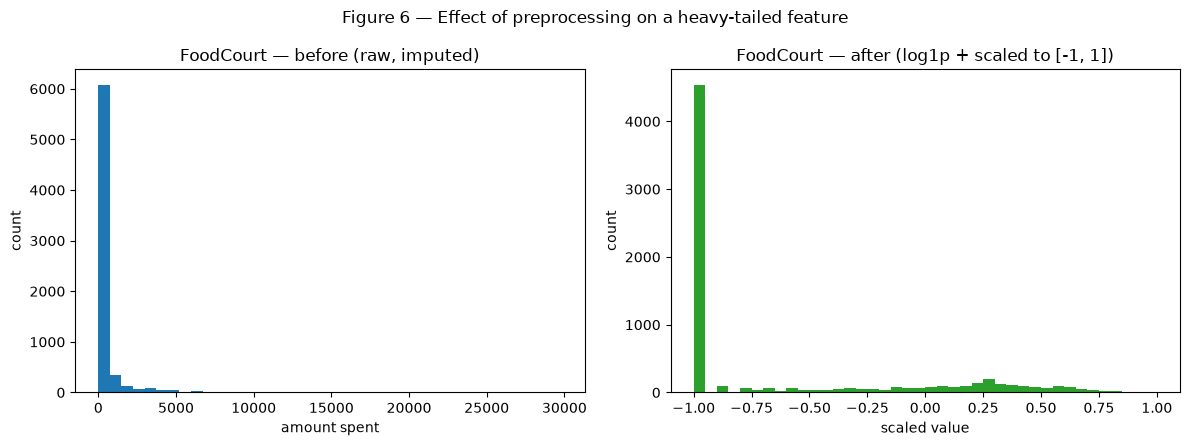

In [12]:
fc_after = Xtr["FoodCourt"].to_numpy()  # log1p + scaled to [-1, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(fc_before, bins=40, color="#1f77b4")
axes[0].set_title("FoodCourt — before (raw, imputed)")
axes[0].set_xlabel("amount spent")
axes[0].set_ylabel("count")
axes[1].hist(fc_after, bins=40, color="#2ca02c")
axes[1].set_title("FoodCourt — after (log1p + scaled to [-1, 1])")
axes[1].set_xlabel("scaled value")
axes[1].set_ylabel("count")
fig.suptitle("Figure 6 — Effect of preprocessing on a heavy-tailed feature")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_foodcourt.png", dpi=150)
plt.show()

### Final checks

In [13]:
n_nan = int(np.isnan(X_train_final).sum() + np.isnan(X_test_final).sum())
print(f"Remaining NaN in feature matrices: {n_nan}")
print(f"Final training feature matrix shape: {X_train_final.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Value range — train: [{X_train_final.min():.3f}, {X_train_final.max():.3f}], "
      f"test: [{X_test_final.min():.3f}, {X_test_final.max():.3f}]  (tanh-compatible)")

Remaining NaN in feature matrices: 0
Final training feature matrix shape: (6954, 17)
Number of features: 17
Value range — train: [-1.000, 1.000], test: [-1.000, 1.138]  (tanh-compatible)
